# CoffeaCasa: executor configuration

One of the core ideas behind `coffea-workflow` is that your **analysis code is completely unaware of how it is executed**.
The `run_analysis` builder receives a coffea executor and runs — it does not know or care whether that executor
uses one thread, 40 Dask workers, or 10 HTCondor jobs on lxplus.

All execution control lives in `RunConfig`:
- `facility` — *where* to run and how to create the executor
- `executor_config` — *which* executor to use, and extra options (workers, packages, files, custom scheduler)

This notebook shows every option available on coffea-casa.

In [1]:
import sys
sys.path.insert(0, "..")

from coffea_workflow import Step, Workflow, Fileset, Analysis, Plotting, RunConfig, ExecutorConfig, render
from coffea_workflow.facilities import CoffeaCasaFactory
from analysis import get_fileset, run_analysis, plot_results

In [2]:
# user's run_analysis function receives an executor at runtime — user never constructs one inside the analysis code
step_fileset = Step(name="Fileset", step_type=Fileset, builder=get_fileset)
step_analysis = Step(name="Analysis", step_type=Analysis, builder=run_analysis) # this builder will recieve the executor from this workflow layer
step_plotting = Step(name="Plotting", step_type=Plotting, builder=plot_results)

workflow = Workflow()
workflow.add(step_fileset)
workflow.add(step_analysis, depends_on=[step_fileset])
workflow.add(step_plotting, depends_on=[step_analysis])

Step(name='Plotting', step_type=<class 'coffea_workflow.artifacts.Plotting'>, builder=<function plot_results at 0x7f628af20180>, builder_params=None, facility=None, executor_config=None)

## Option 1. Simplest: let the factory do it all

`CoffeaCasaFactory` connects to the pre-configured scheduler at `tls://localhost:8786`.
The default executor is `executor_type="DaskExecutor"` if no `executor_config` specified. When using `facility=CoffeaCasaFactory()`, the factory handles the `Client` setup and uses `DaskExecutor` but then Dask should have a proper version of coffea (with `use_result_type=True, skipbadfiles=True`.

Workflow DAG:
  [0] Fileset -> Fileset builder=<function get_fileset at 0x7f628aeffba0>
  [1] Analysis -> Analysis builder=<function run_analysis at 0x7f628aeffe20>
  [2] Plotting -> Plotting builder=<function plot_results at 0x7f628af20180>
Edges:
  Fileset -> Analysis
  Analysis -> Plotting
Executing step 'Fileset' of type 'Fileset' with the user code <function get_fileset at 0x7f628aeffba0> and user parameters None
Extracted from cache: .cache_coffea_casa/Fileset/22c2cc185640e94941a58e99ac76a71eff60afb8890cd48945c40208ad50cd89
  -> materialized at .cache_coffea_casa/Fileset/22c2cc185640e94941a58e99ac76a71eff60afb8890cd48945c40208ad50cd89
Executing step 'Analysis' of type 'Analysis' with the user code <function run_analysis at 0x7f628aeffe20> and user parameters None
Extracted from cache: .cache_coffea_casa/Chunking/0370682774a2c9d78692884505552121b77c8c7500cbef254193a9b2e8a478ba

Split strategy applied, starting independent processing of 10 fileset subsets...

chunk_fraction=0.3: pr

Output()

/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py:1278: UserWarning: Performed attempt 1 out of 4
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py:1278: UserWarning: Performed attempt 2 out of 4
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py:1278: UserWarning: Performed attempt 3 out of 4
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py:1278: UserWarning: Performed attempt 4 out of 4
  warnings.warn(


loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 490, in _process_worker
    r = call_item()
        ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py", line 1290, in automatic_retries
    raise e
  File "/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py", line 1276, in automatic_retries
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py", line 1360, in metadata_fetcher_root
    with uproot.open(
         ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/uproot/reading.py", line 144, in open
    file = ReadOnlyFile(
           ^^^^^^

Failure caught!
------------------------------------
Processing fileset_chunk_1.json
Extracted from cache: .cache_coffea_casa/ChunkAnalysis/828b42b4a82b6117f8ef44a4fc1095a8da17eb420841eb85c5550765acd2b9d6
Successfully processed!
------------------------------------
Processing fileset_chunk_2.json
Extracted from cache: .cache_coffea_casa/ChunkAnalysis/62800d4d5f08853d40d2aa3c38168f39afed79f0659358f8a2568c3abca555d8
Successfully processed!
  -> materialized at .cache_coffea_casa/Analysis/af829d369589e92f54ed6fb97c33479dfb18a10803721c01befc641c6a8bc24f
Executing step 'Plotting' of type 'Plotting' with the user code <function plot_results at 0x7f628af20180> and user parameters None
  -> materialized at .cache_coffea_casa/Plotting/f11779c4df64250ab8c330aef9ce1d9ecc13707610b186497e16e6a72798239b

=== Run Summary ===
  ✓  Fileset                        Fileset
  !  Analysis                       Analysis             2/3 chunks OK
       FAILED fileset_chunk_0.json: Err(OSError('XRootD error: 

{'paths': {'Fileset': PosixPath('.cache_coffea_casa/Fileset/22c2cc185640e94941a58e99ac76a71eff60afb8890cd48945c40208ad50cd89'),
  'Analysis': PosixPath('.cache_coffea_casa/Analysis/af829d369589e92f54ed6fb97c33479dfb18a10803721c01befc641c6a8bc24f'),
  'Plotting': PosixPath('.cache_coffea_casa/Plotting/f11779c4df64250ab8c330aef9ce1d9ecc13707610b186497e16e6a72798239b')},
 'results': {'Fileset': {'SingleMu_0': {'files': {'root://eeeospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A41320F6-C9F9-574C-8DD2-BD98C200E4EE.root': 'Events',
     'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A7FEFB1C-387F-2B4D-A111-C53CC9371EC7.root': 'Events',
     'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWW

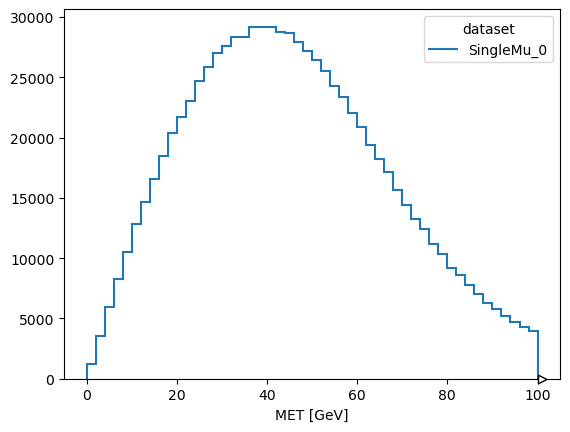

In [3]:
config = RunConfig(
    strategy="by_dataset",
    percentage=20,
    chunk_fraction=0.3,
    cache_dir=".cache_coffea_casa",
    facility=CoffeaCasaFactory(),
    executor_config=ExecutorConfig(executor_type="FuturesExecutor"),
)

render(workflow, config)

In [4]:
# import subprocess
# subprocess.run(["pip", "wheel", "git+https://github.com/hooloobooroodkoo/coffea.git@master", 
#                 "-w", "./dist/", "--no-deps"], check=True)

In [5]:
# config = RunConfig(
#     strategy="by_dataset",
#     percentage=20,
#     chunk_fraction=0.3,
#     cache_dir=".cache_coffea_casa_dask",
#     facility=CoffeaCasaFactory(),
#     executor_config=ExecutorConfig(
#         executor_type="DaskExecutor",
#         worker_packages=("./dist/coffea-0.1.dev4336+gee1c702ee-py3-none-any.whl",),
#         worker_files=("../analysis.py", "./dist/coffea-0.1.dev4336+gee1c702ee-py3-none-any.whl"),
#     ),
# )

# render(workflow, config)

Workflow DAG:
  [0] Fileset -> Fileset builder=<function get_fileset at 0x7f527d447d80>
  [1] Analysis -> Analysis builder=<function run_analysis at 0x7f527d478040>
  [2] Plotting -> Plotting builder=<function plot_results at 0x7f527d478360>
Edges:
  Fileset -> Analysis
  Analysis -> Plotting
Executing step 'Fileset' of type 'Fileset' with the user code <function get_fileset at 0x7f527d447d80> and user parameters None
Extracted from cache: .cache_coffea_casa_dask/Fileset/22c2cc185640e94941a58e99ac76a71eff60afb8890cd48945c40208ad50cd89
  -> materialized at .cache_coffea_casa_dask/Fileset/22c2cc185640e94941a58e99ac76a71eff60afb8890cd48945c40208ad50cd89
Executing step 'Analysis' of type 'Analysis' with the user code <function run_analysis at 0x7f527d478040> and user parameters None
Extracted from cache: .cache_coffea_casa_dask/Chunking/0370682774a2c9d78692884505552121b77c8c7500cbef254193a9b2e8a478ba
Connecting to Dask scheduler...
Uploaded ../analysis.py to workers
Uploaded ./dist/coffea-

Output()

KeyboardInterrupt: 